In [2]:
# Install the Ultralytics library for YOLOv8
!pip install ultralytics

In [4]:
# Import required libraries
import torch
import ultralytics
from ultralytics import YOLO

# Check Ultralytics version and GPU availability
print("Ultralytics version:", ultralytics.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.170
GPU available: True
GPU name: Tesla T4


In [5]:
# Load a pre-trained YOLOv8 nano model
model = YOLO("yolov8n.pt")

# Define the dataset configuration file
dataset = "coco128.yaml"

print("YOLOv8 model successfully loaded")
print("Dataset:", dataset)

YOLOv8 model successfully loaded
Dataset: coco128.yaml


In [6]:
# Train the YOLOv8 neural network on the dataset

results = model.train(
    data=dataset,
    epochs=10,
    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu",
    project="runs/detect",
    name="lr1_yolov8",
    plots=True
)

print("Training completed!")

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lr1_yolov8, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, ov

In [7]:
# Evaluate the trained YOLOv8 model and calculate metrics

metrics = model.val(data=dataset)

print("\nMODEL EVALUATION RESULTS")
print("-" * 40)

print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1750.4±461.2 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 38.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.9it/s 2.8s
                   all        128        929      0.707      0.676      0.725      0.545
                person         61        254      0.827      0.714      0.793      0.575
               bicycle          3          6      0.846      0.333      0.462      0.406
                   car         12         46      0.632      0.299      0.381      0.222
            motorcycle          4          5       0.78        0.8      0.938      0.787
              airplane          5    

In [8]:
# Display the training results graph generated by YOLOv8

from IPython.display import Image, display
import os

plot_path = "runs/detect/lr1_yolov8/results.png"

if os.path.exists(plot_path):
    display(Image(filename=plot_path))
else:
    print("Training results graph not found")

Training results graph not found


In [9]:
# Check the available training result folders
import os

for root, dirs, files in os.walk("runs"):
    print("Folder:", root)
    for file in files:
        print("  File:", file)

Folder: runs
Folder: runs/detect
Folder: runs/detect/runs
Folder: runs/detect/runs/detect
Folder: runs/detect/runs/detect/lr1_yolov8
  File: results.csv
  File: BoxR_curve.png
  File: train_batch1.jpg
  File: val_batch2_pred.jpg
  File: confusion_matrix_normalized.png
  File: val_batch1_pred.jpg
  File: val_batch1_labels.jpg
  File: results.png
  File: BoxPR_curve.png
  File: BoxP_curve.png
  File: val_batch2_labels.jpg
  File: confusion_matrix.png
  File: labels.jpg
  File: train_batch2.jpg
  File: val_batch0_labels.jpg
  File: val_batch0_pred.jpg
  File: train_batch0.jpg
  File: BoxF1_curve.png
  File: args.yaml
Folder: runs/detect/runs/detect/lr1_yolov8/weights
  File: best.pt
  File: last.pt
Folder: runs/detect/val
  File: BoxR_curve.png
  File: val_batch2_pred.jpg
  File: confusion_matrix_normalized.png
  File: val_batch1_pred.jpg
  File: val_batch1_labels.jpg
  File: BoxPR_curve.png
  File: BoxP_curve.png
  File: val_batch2_labels.jpg
  File: confusion_matrix.png
  File: val_batc

Training graph found: runs/detect/runs/detect/lr1_yolov8/results.png


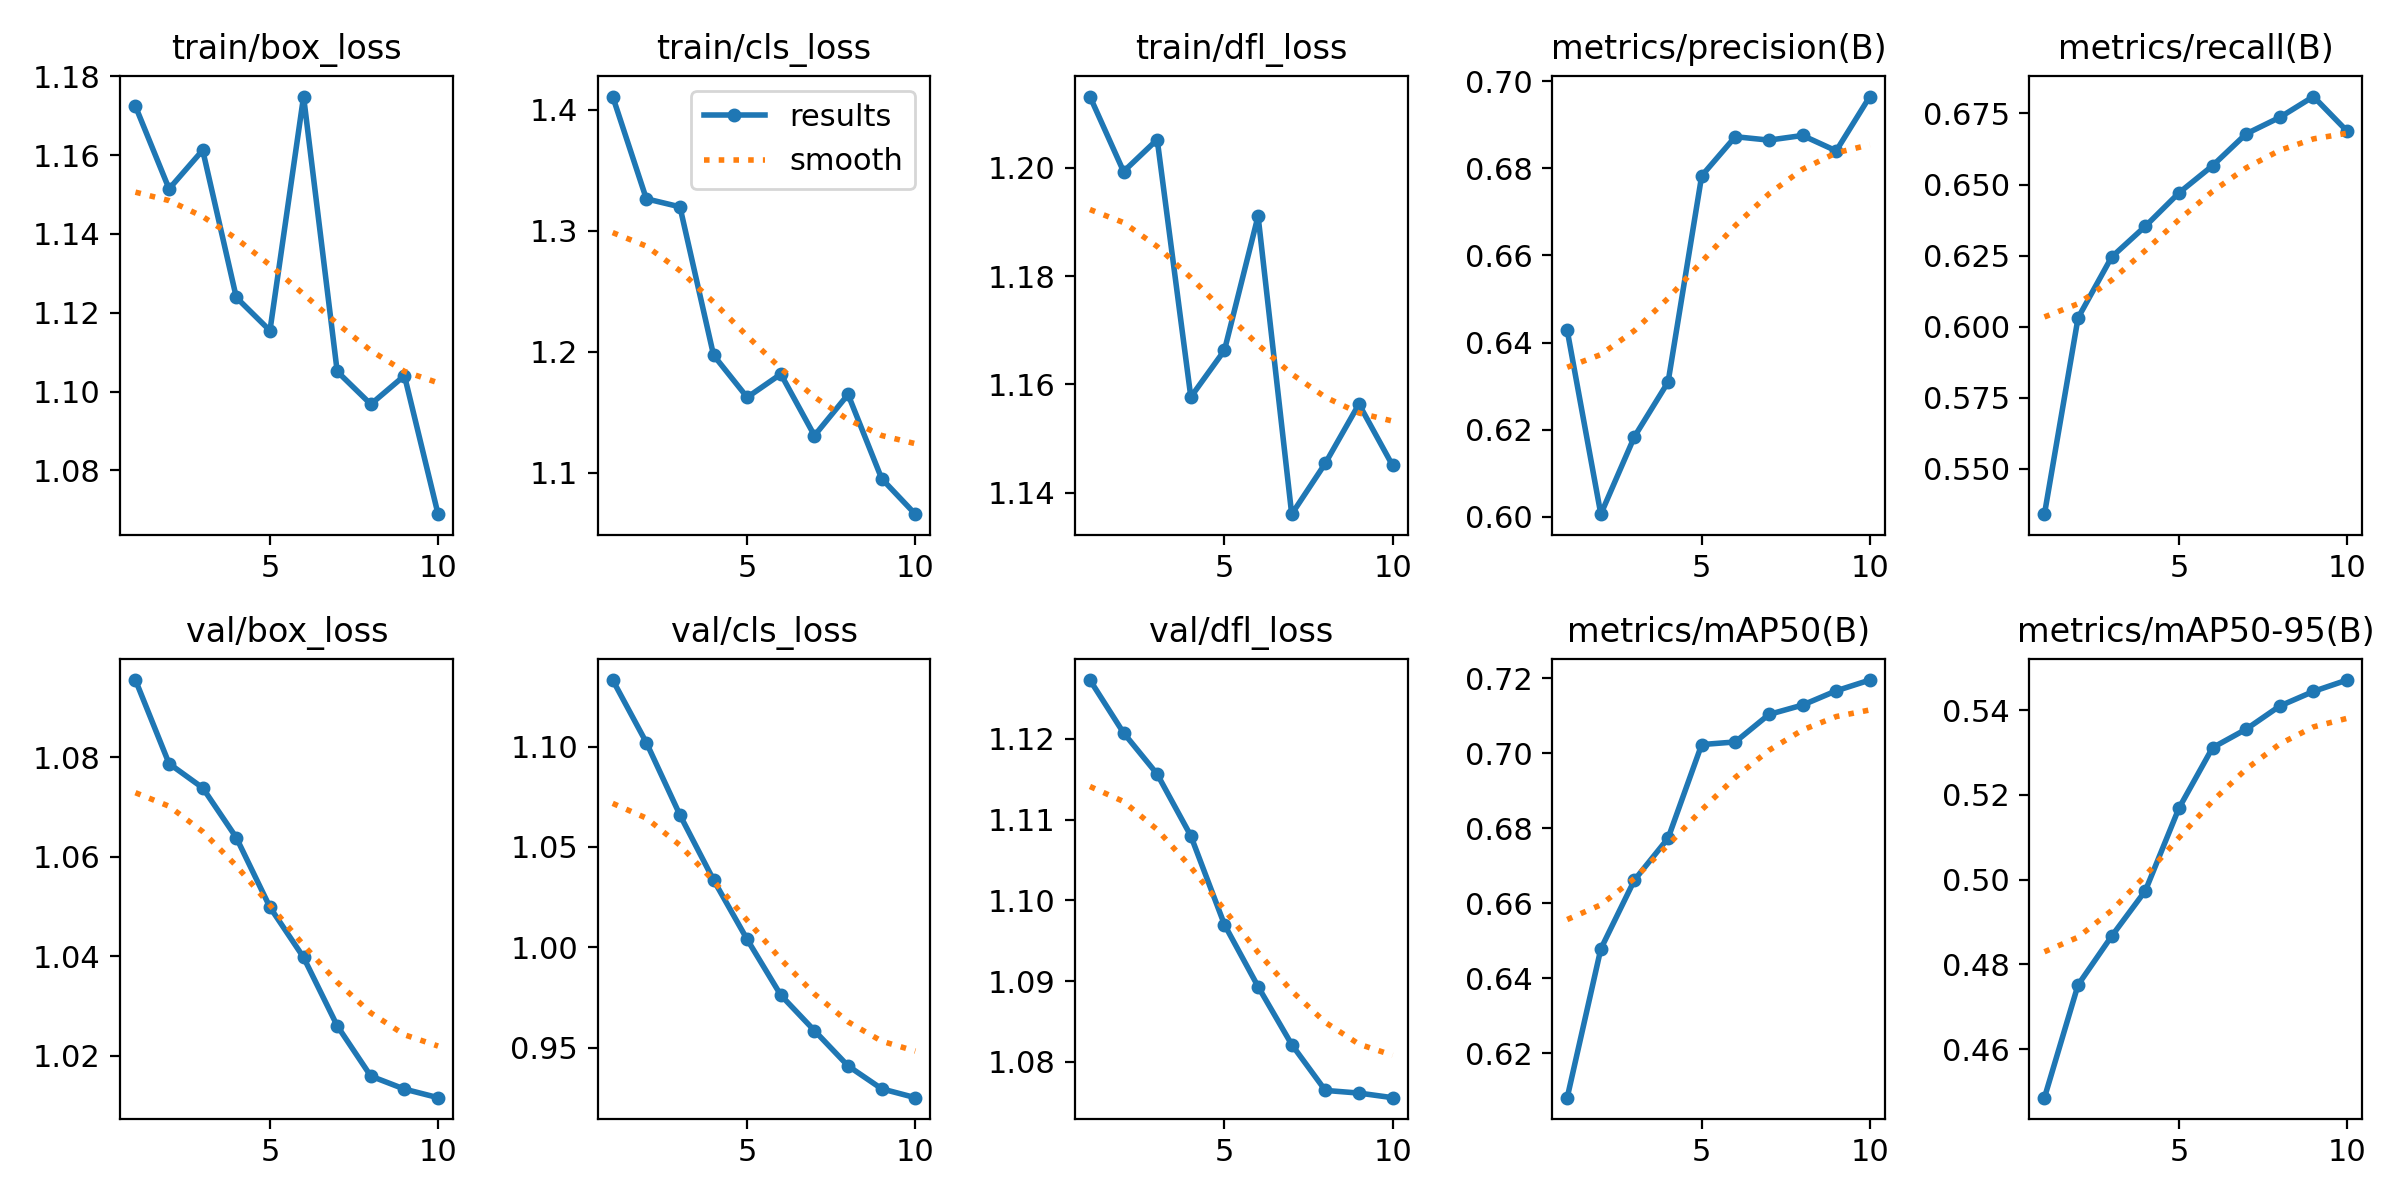

In [10]:
# Find and display the YOLOv8 training results graph
import glob
from IPython.display import Image, display

graphs = glob.glob("runs/detect/**/results.png", recursive=True)

if graphs:
    for graph in graphs:
        print("Training graph found:", graph)
        display(Image(filename=graph))
else:
    print("No training graph found. Please run the training cell first.")